# KDE

In [1]:
import astropy.coordinates as coord 
from astropy.table import Table 
import astropy.units as u 
 
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline 
from scipy.stats import norm 
from scipy.special import logsumexp 
from scipy.optimize import minimize 
from sklearn.neighbors import KernelDensity 
from sklearn.model_selection import GridSearchCV

In [2]:
np.random.seed(42) 
x1 = np.random.normal(0.25, 0.1, size=200) 
x2 = np.random.normal(1., 0.5, size=1000) 
x = np.concatenate((x1, x2)) 
np.random.shuffle(x) # we'll rely on this later! 
 
def true_x_density(x): 
    return ((1/6)*norm.pdf(x, loc=0.25, scale=0.1) +  
            (5/6)*norm.pdf(x, loc=1., scale=0.5))

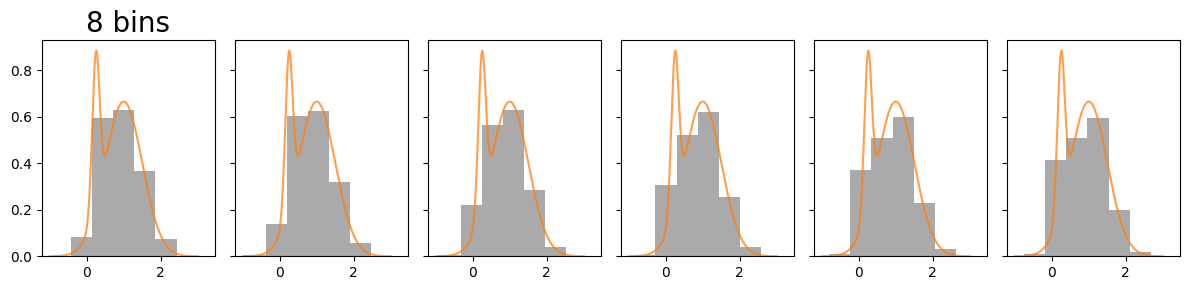

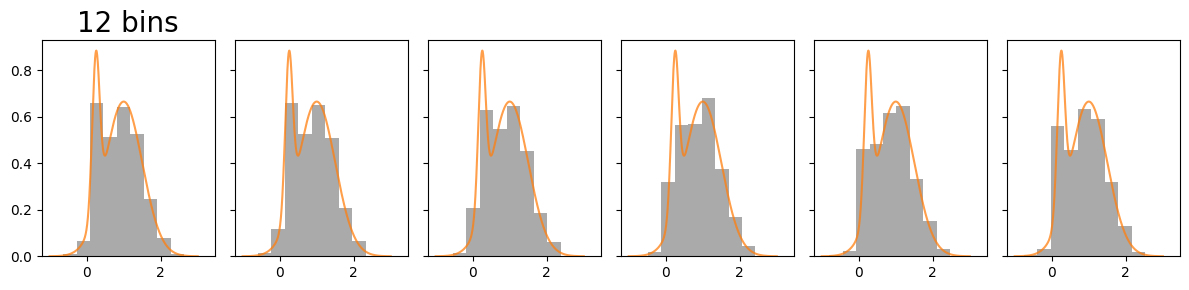

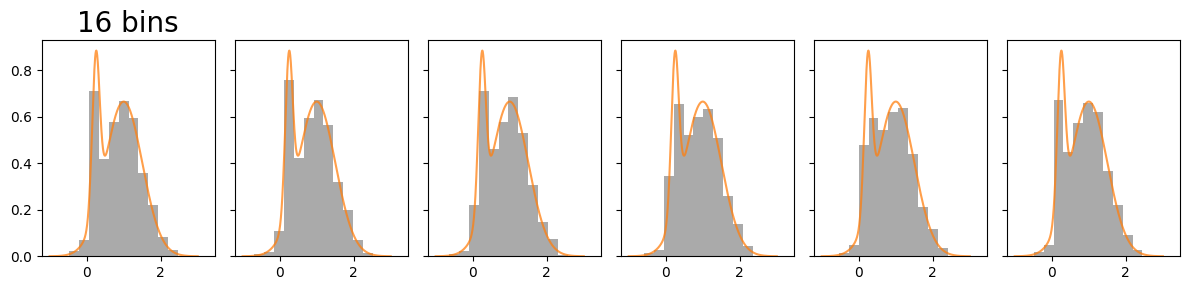

In [3]:
for n_bins in [8, 12, 16]: 
    bins = np.linspace(-1, 3, n_bins) 
 
    fig, axes = plt.subplots(1, 6, figsize=(12, 3),  
                             sharex=True, sharey=True) 
     
    x_grid = np.linspace(-1, 3, 1000) 
    for i, ax in enumerate(axes.flat): 
        ax.hist(x, bins=bins + i/20, density=True, color='#aaaaaa') 
        ax.plot(x_grid, true_x_density(x_grid), marker='',  
                alpha=0.75, zorder=10, color='tab:orange') 
     
    axes[0].set_title('{0} bins'.format(n_bins), fontsize=20) 
    fig.tight_layout()

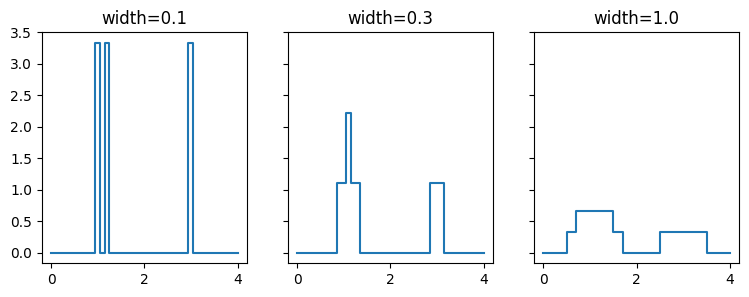

In [5]:
def point_centered_histogram(x, bin_width, data): 
    data = np.array(data) 
    x = np.array(x) 
    y = (data[None] - x[:, None]) / (bin_width/2.) 
    return np.sum(np.abs(y) < 1., axis=1) / (len(data) * bin_width)

x_grid = np.linspace(0, 4, 512) 
data = [1., 1.2, 3.] 
bin_widths = [0.1, 0.3, 1.] 
 
fig, axes = plt.subplots(1, 3, figsize=(9, 3), sharex=True, sharey=True) 
 
for i, ax in enumerate(axes.flat): 
    ax.plot(x_grid, point_centered_histogram(x_grid, bin_widths[i], data),  
            marker='', drawstyle='steps-mid') 
     
    ax.set_title('width={0:.1f}'.format(bin_widths[i]))

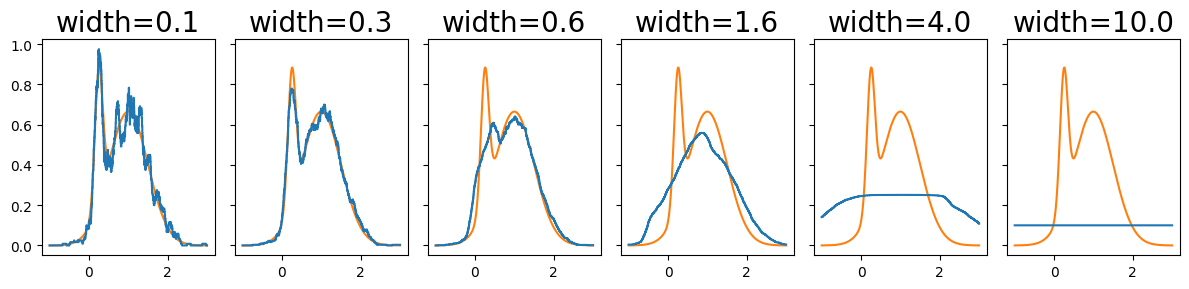

In [6]:
fig, axes = plt.subplots(1, 6, figsize=(12, 3),  
                         sharex=True, sharey=True) 
 
bin_widths = np.logspace(-1, 1, len(axes)) 
 
x_grid = np.linspace(-1, 3, 1024) 
for i, ax in enumerate(axes.flat): 
    ax.plot(x_grid, point_centered_histogram(x_grid, bin_widths[i], x),  
            marker='', drawstyle='steps-mid') 
     
    ax.plot(x_grid, true_x_density(x_grid),  
            zorder=-10, marker='') 
 
    ax.set_title('width={0:.1f}'.format(bin_widths[i]), fontsize=20) 
fig.tight_layout() 
 
# Show the figure 
plt.tight_layout()

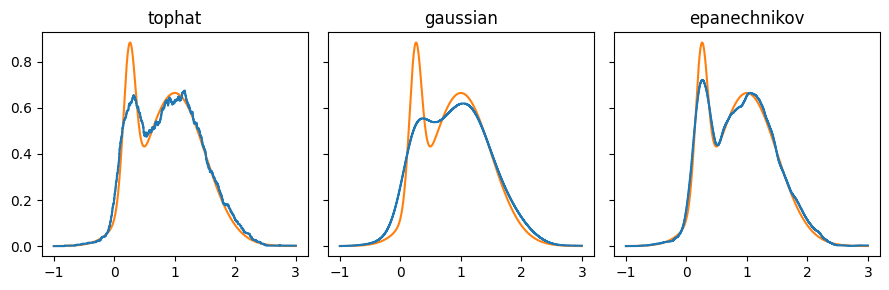

In [11]:
kde_tophat = KernelDensity(bandwidth=0.2, kernel='tophat') 
kde_gauss = KernelDensity(bandwidth=0.2, kernel='gaussian') 
kde_epan = KernelDensity(bandwidth=0.2, kernel='epanechnikov') 
kdes = [kde_tophat, kde_gauss, kde_epan] 
 
X = x.reshape(-1, 1) 
for kde in kdes: 
    kde.fit(X) 
 
fig, axes = plt.subplots(1, 3, figsize=(9, 3),  
                         sharex=True, sharey=True) 
 
x_grid = np.linspace(-1, 3, 1024) 
for ax, kde in zip(axes.flat, kdes): 
    ax.plot(x_grid, np.exp(kde.score_samples(x_grid.reshape(-1, 1))), 
            marker='', drawstyle='steps-mid') 
     
    ax.plot(x_grid, true_x_density(x_grid),  
            zorder=-10, marker='', color='tab:orange')
         
    ax.set_title(kde.kernel) 
     
fig.tight_layout()


In [13]:
def cv_neg_ln_likelihood(p): 
    ln_b = p[0] 
    kde_gauss = KernelDensity(bandwidth=np.exp(ln_b), kernel='gaussian') 
    kde_gauss.fit(train_x.reshape(-1, 1)) 
    return -np.sum(kde_gauss.score_samples(test_x.reshape(-1, 1)))

bs = [] 
 
idx = np.arange(x.size) 
 
# We'll only do 128 iterations, instead of running through the entire dataset! 
for i in range(128): 
    rand_i = np.random.randint(0, x.size, size=32) # K = 32 
    test_x = x[rand_i] 
    train_x = x[np.logical_not(np.isin(idx, rand_i))] 
 
    res = minimize(cv_neg_ln_likelihood, x0=-1) 
    bs.append(np.exp(res.x[0])) 
 
best_b = np.mean(bs) 
best_b 

np.float64(0.09155566461581388)

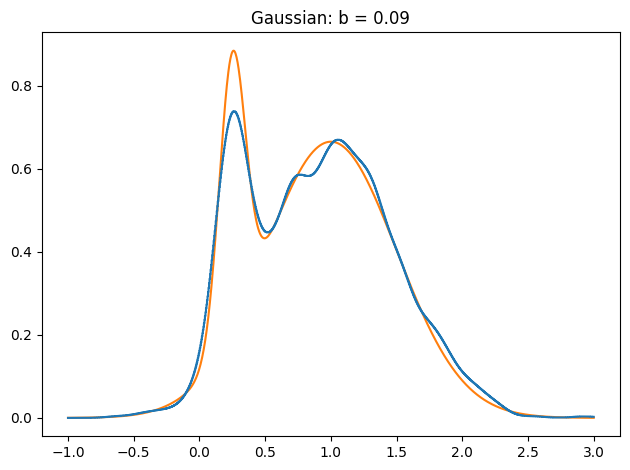

In [14]:
kde_gauss = KernelDensity(bandwidth=best_b, kernel='gaussian') 
kde_gauss.fit(x.reshape(-1, 1)) 
 
plt.plot(x_grid, np.exp(kde_gauss.score_samples(x_grid.reshape(-1, 1))), 
         marker='', drawstyle='steps-mid') 
plt.plot(x_grid, true_x_density(x_grid),  
         zorder=-10, marker='', color='tab:orange') 
plt.title('Gaussian: b = {0:.2f}'.format(best_b))
plt.tight_layout()